In [1]:
import sys, os
from utils import * 


In [2]:
import joblib

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("ULB_data.pkl")
y_test = y_test.values.ravel()

MODEL_NAME = "GMM_EM"
DE_LONG_RESULTS = "ULB_all_results.pkl"
METRICS = "ULB_metrics.pkl"


In [3]:
# ================================================================
# ================================================================
# ================================================================
# ================================================================
# ================================================================
# =================== 5. GMM with EM algorithm ===================
# ================================================================
# ================================================================
# ================================================================
# ================================================================
# ================================================================

In [4]:
# ===================== 5. GMM with EM algorithm =====================
GMM_train_scores, GMM_test_scores, GMM_model = run_gmm(X_train, X_test, n_components=GMM_N_COMPONENTS)


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7


In [5]:
# ===================== Store metrics =====================
GMM_metrics = store_anomaly_metrics(y_true=y_test, scores=GMM_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)
display(GMM_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,GMM_EM,creditcard,0.010881,0.007-0.015,0.316327,0.224-0.406,0.021038,0.014-0.028,0.757764,0.709-0.801,0.012096,0.006-0.024,"[[54046, 2818], [67, 31]]",27.936738


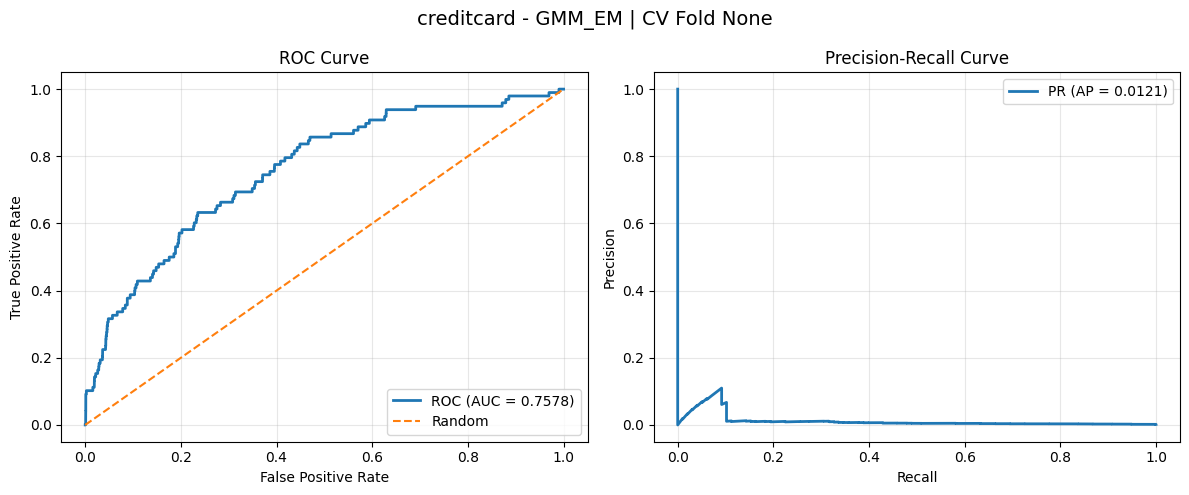

In [6]:
# ===================== Plot results =====================
plot_anomaly_roc_pr(y_true=y_test, scores=GMM_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)

In [8]:
# ===================== Fit on CV folds =====================
GMM_cv_results = fit_cross_validate(X_train, y_train, X_test, y_test, run_gmm, DATASET_NAME, MODEL_NAME, CV_FOLDS, RANDOM_STATE)


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7


In [9]:
# ===================== Store CV metrics =====================

GMM_cv_metrics = pd.concat([r["test_metrics"] for r in GMM_cv_results], ignore_index=True)
display(GMM_cv_metrics)



,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,GMM_EM_Fold1,creditcard,0.010881,0.007-0.015,0.316327,0.224-0.406,0.021038,0.014-0.028,0.756015,0.707-0.800,0.012099,0.006-0.024,"[[54046, 2818], [67, 31]]",27.964118
1,GMM_EM_Fold2,creditcard,0.010881,0.007-0.015,0.316327,0.224-0.406,0.021038,0.014-0.028,0.757495,0.709-0.801,0.012162,0.006-0.025,"[[54046, 2818], [67, 31]]",27.937815
2,GMM_EM_Fold3,creditcard,0.010881,0.007-0.015,0.316327,0.224-0.406,0.021038,0.014-0.028,0.757320,0.708-0.801,0.012074,0.006-0.024,"[[54046, 2818], [67, 31]]",27.946842
3,GMM_EM_Fold4,creditcard,0.010881,0.007-0.015,0.316327,0.224-0.406,0.021038,0.014-0.028,0.756068,0.707-0.800,0.012003,0.006-0.024,"[[54046, 2818], [67, 31]]",27.943099
4,GMM_EM_Fold5,creditcard,0.010881,0.007-0.015,0.316327,0.224-0.406,0.021038,0.014-0.028,0.756586,0.708-0.801,0.012036,0.006-0.024,"[[54046, 2818], [67, 31]]",27.948604


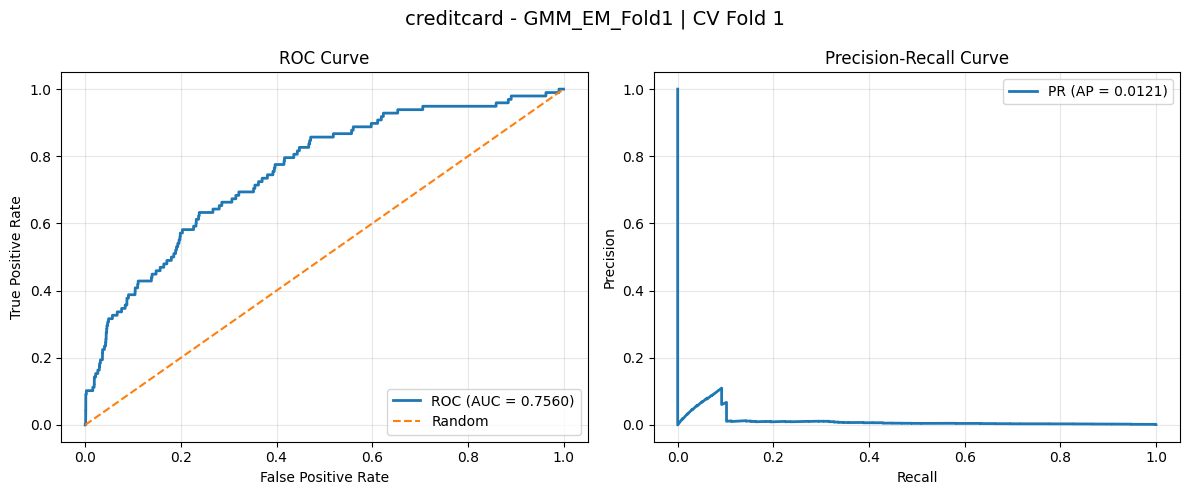

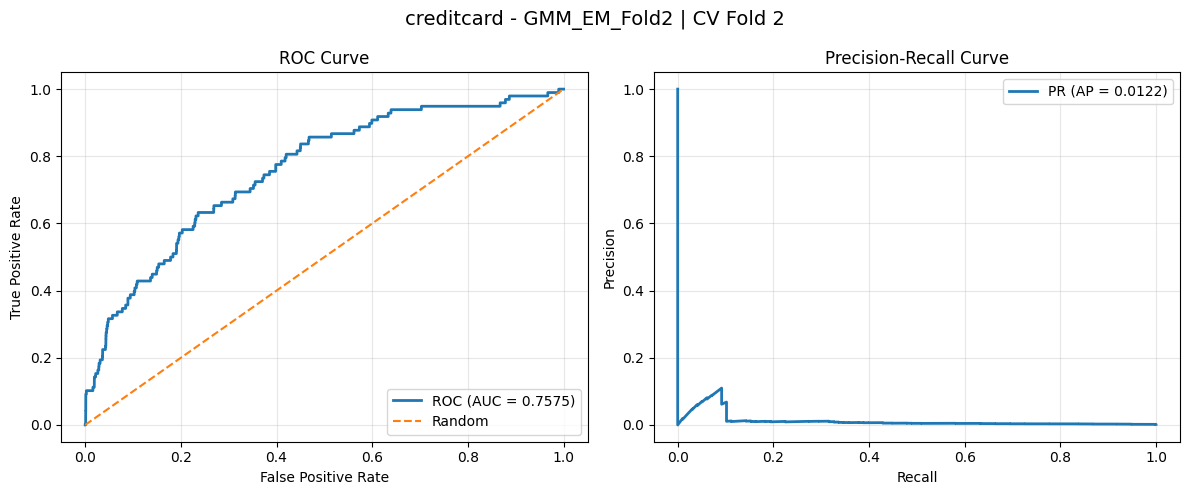

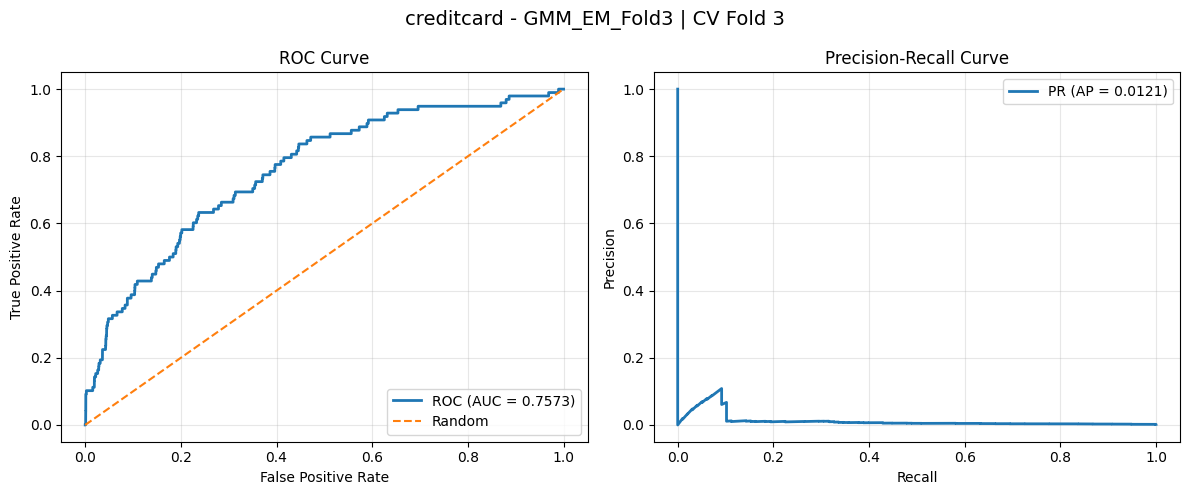

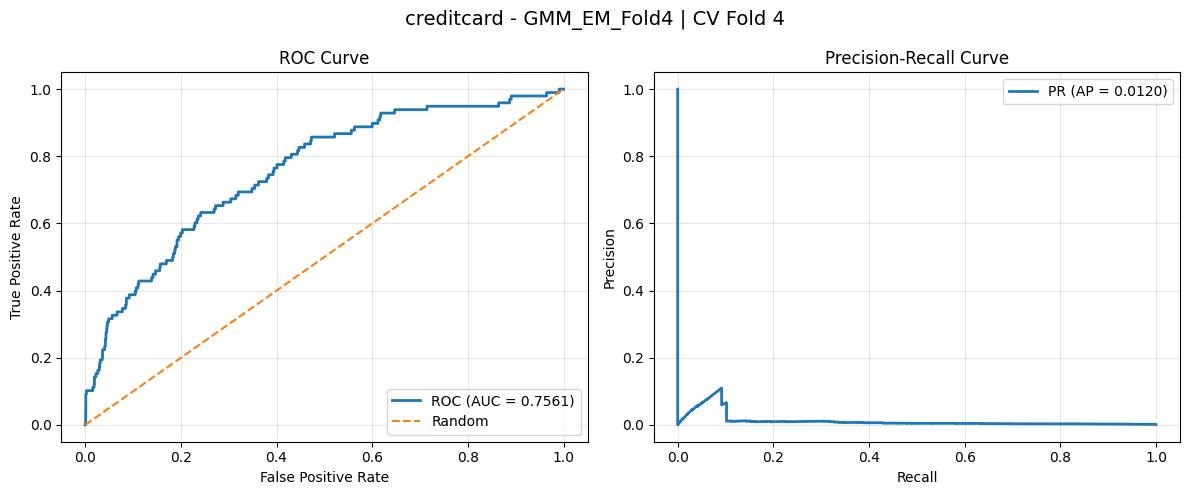

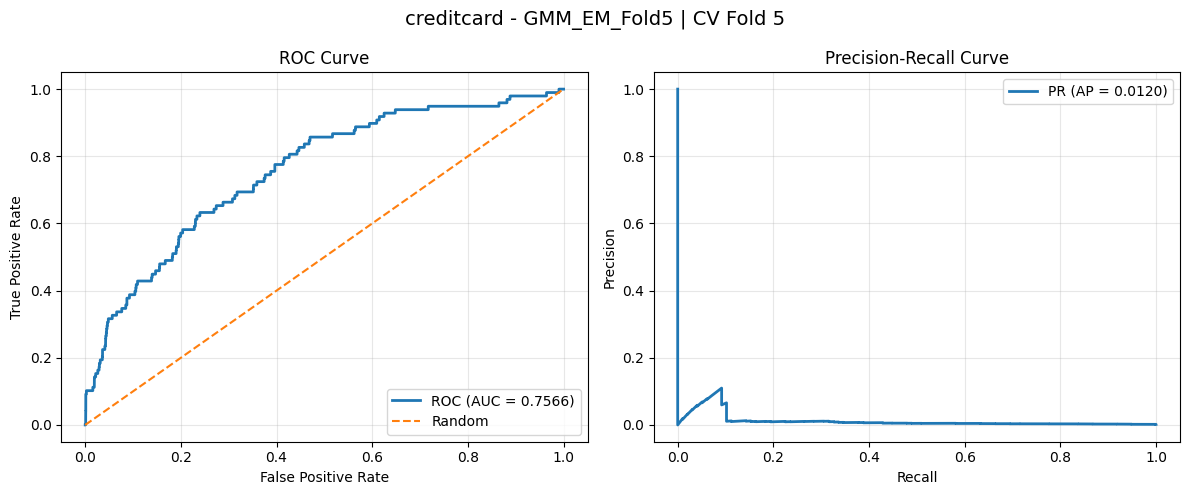

In [10]:
# ===================== Plot CV results =====================

for r in GMM_cv_results:
    plot_anomaly_roc_pr(y_test, r["test_scores"], DATASET_NAME, f"{MODEL_NAME}_Fold{r['fold']}", r["fold"])


In [11]:
if os.path.exists(DE_LONG_RESULTS):
    results = joblib.load(DE_LONG_RESULTS)
else:
    results = {}

results[MODEL_NAME] = {
    "test_scores": GMM_test_scores,
    "auc": roc_auc_score(y_test, GMM_test_scores)
}

joblib.dump(results, DE_LONG_RESULTS)

['ULB_all_results.pkl']

In [12]:
if os.path.exists(METRICS):
    results = joblib.load(METRICS)
else:
    results = {}

results[MODEL_NAME] = {
    "metrics": GMM_metrics,
    "cv_metrics": GMM_cv_metrics
}

joblib.dump(results, METRICS)

['ULB_metrics.pkl']